# Kunqu Opera — Audio & Motion Synchrony Analysis

This notebook explores the aligned signals produced by the pipeline, focusing on
cross-modal rhythmic synchronization between audio (singing/music) and motion (body movement).

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.stats import pearsonr

VIDEO_ID = "xunmeng"

# Load aligned signals
data = np.load(f"../data/processed/{VIDEO_ID}_aligned_signals.npz")
with open(f"../data/processed/{VIDEO_ID}_aligned_signals.json") as f:
    meta = json.load(f)

# Load shot boundaries
with open(f"../data/processed/{VIDEO_ID}_shot_boundaries.json") as f:
    shot_data = json.load(f)

fps = meta["common_fps"]
times = data["times"]
cut_mask = data["cut_mask"].astype(bool)

print(f"Video: {VIDEO_ID}")
print(f"Duration: {meta['total_duration_sec']:.1f}s ({meta['total_frames']} frames @ {fps}fps)")
print(f"Cuts: {shot_data['num_cuts']}")
print(f"Motion NaN fraction: {meta['nan_fraction_motion']:.1%}")
print(f"\nAvailable signals: {sorted(data.files)}")

Video: xunmeng
Duration: 1494.3s (44829 frames @ 30fps)
Cuts: 19
Motion NaN fraction: 34.3%

Available signals: ['audio_f0', 'audio_onset', 'audio_pitch_delta', 'audio_rms', 'cut_mask', 'motion_hand', 'motion_hand_left', 'motion_hand_right', 'motion_head', 'motion_root_displacement', 'motion_torso', 'motion_total', 'motion_upper_body', 'times']


## 1. Signal Overview

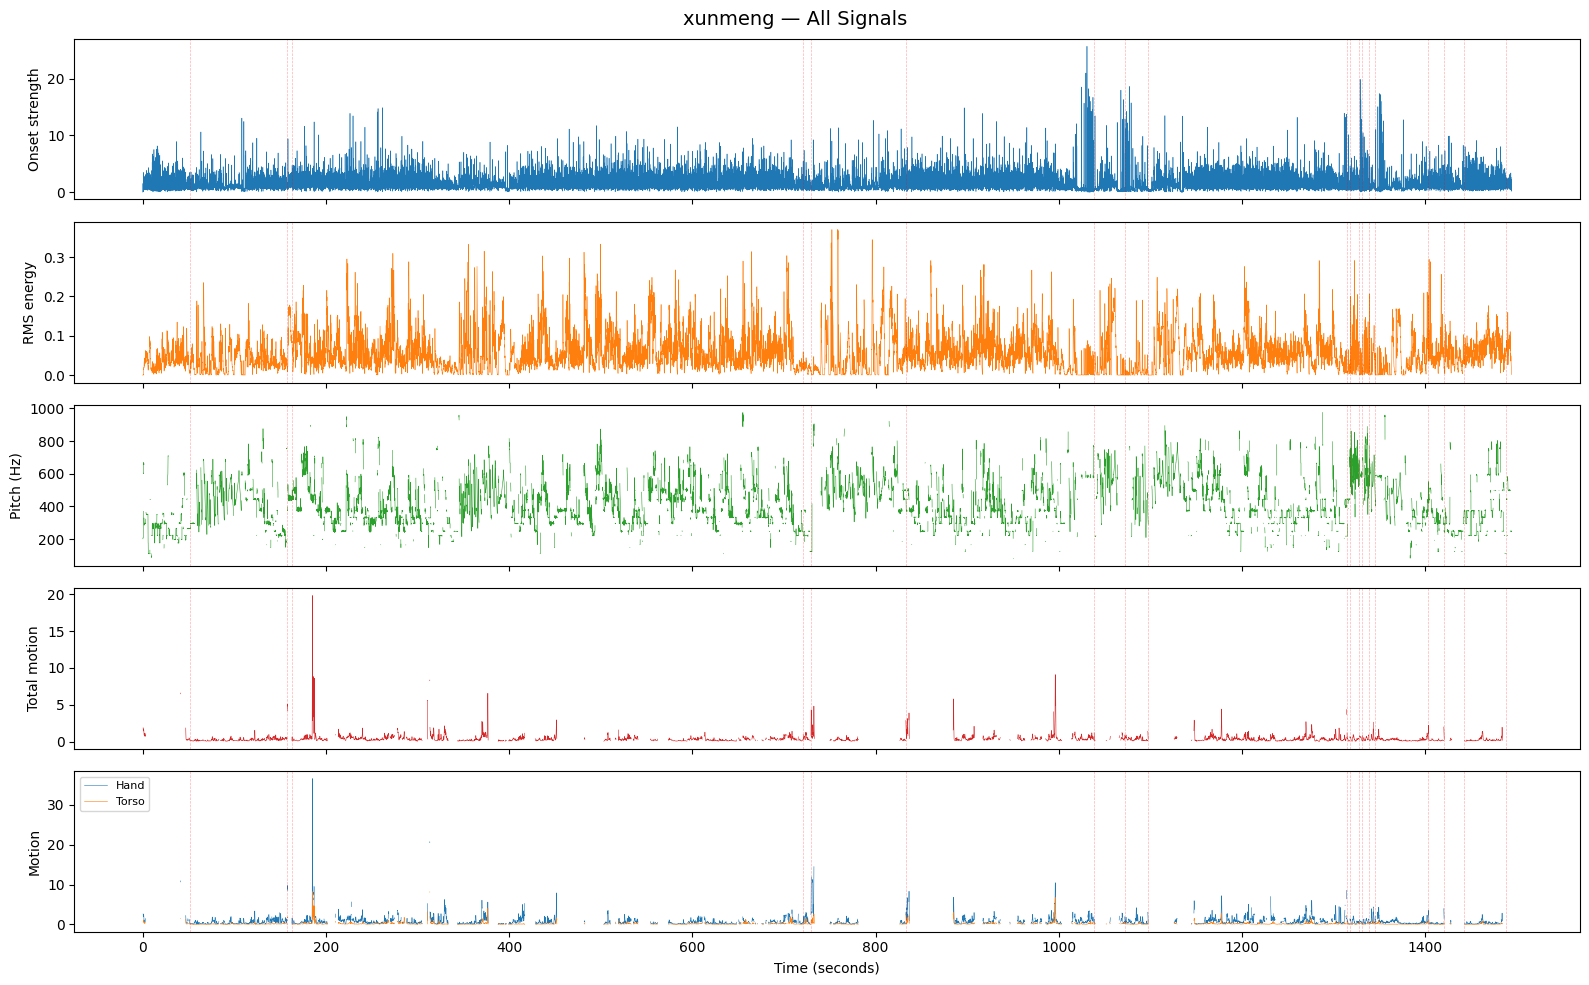

In [2]:
fig, axes = plt.subplots(5, 1, figsize=(16, 10), sharex=True)

axes[0].plot(times, data["audio_onset"], lw=0.4, color="C0")
axes[0].set_ylabel("Onset strength")

axes[1].plot(times, data["audio_rms"], lw=0.4, color="C1")
axes[1].set_ylabel("RMS energy")

axes[2].plot(times, data["audio_f0"], lw=0.4, color="C2")
axes[2].set_ylabel("Pitch (Hz)")

axes[3].plot(times, data["motion_total"], lw=0.4, color="C3")
axes[3].set_ylabel("Total motion")

axes[4].plot(times, data["motion_hand"], lw=0.4, color="C0", label="Hand")
axes[4].plot(times, data["motion_torso"], lw=0.4, color="C1", label="Torso")
axes[4].set_ylabel("Motion")
axes[4].legend(fontsize=8)

axes[-1].set_xlabel("Time (seconds)")

# Mark cuts
for ax in axes:
    for cf in shot_data["cuts"]:
        ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.3, lw=0.5)

fig.suptitle(f"{VIDEO_ID} — All Signals", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Per-Region Correlation with Audio Onset

Which body region tracks the music rhythm most closely?

In [3]:
onset = data["audio_onset"]

motion_signals = {
    "Total body": data["motion_total"],
    "Hand (combined)": data["motion_hand"],
    "Hand left": data["motion_hand_left"],
    "Hand right": data["motion_hand_right"],
    "Torso": data["motion_torso"],
    "Upper body": data["motion_upper_body"],
    "Head": data["motion_head"],
}

print(f"{'Region':<20s}  {'Pearson r':>10s}  {'p-value':>12s}  {'N valid':>10s}")
print("-" * 58)

results = []
for name, sig in motion_signals.items():
    valid = ~np.isnan(sig) & ~np.isnan(onset) & ~cut_mask
    n = valid.sum()
    if n > 100:
        r, p = pearsonr(onset[valid], sig[valid])
        results.append((name, r, p, n))
        print(f"{name:<20s}  {r:>10.4f}  {p:>12.2e}  {n:>10d}")
    else:
        print(f"{name:<20s}  {'(too few valid frames)':>34s}")

Region                 Pearson r       p-value     N valid
----------------------------------------------------------
Total body                0.0251      1.58e-05       29467
Hand (combined)           0.0211      4.32e-04       27826
Hand left                 0.0187      2.41e-03       26250
Hand right                0.0192      3.48e-03       23192
Torso                     0.0241      3.48e-05       29467
Upper body                0.0253      1.39e-05       29467
Head                      0.0228      9.32e-05       29467


## 3. Cross-Correlation (Lag Analysis)

Does motion lead or follow audio events? The peak lag reveals the temporal relationship.

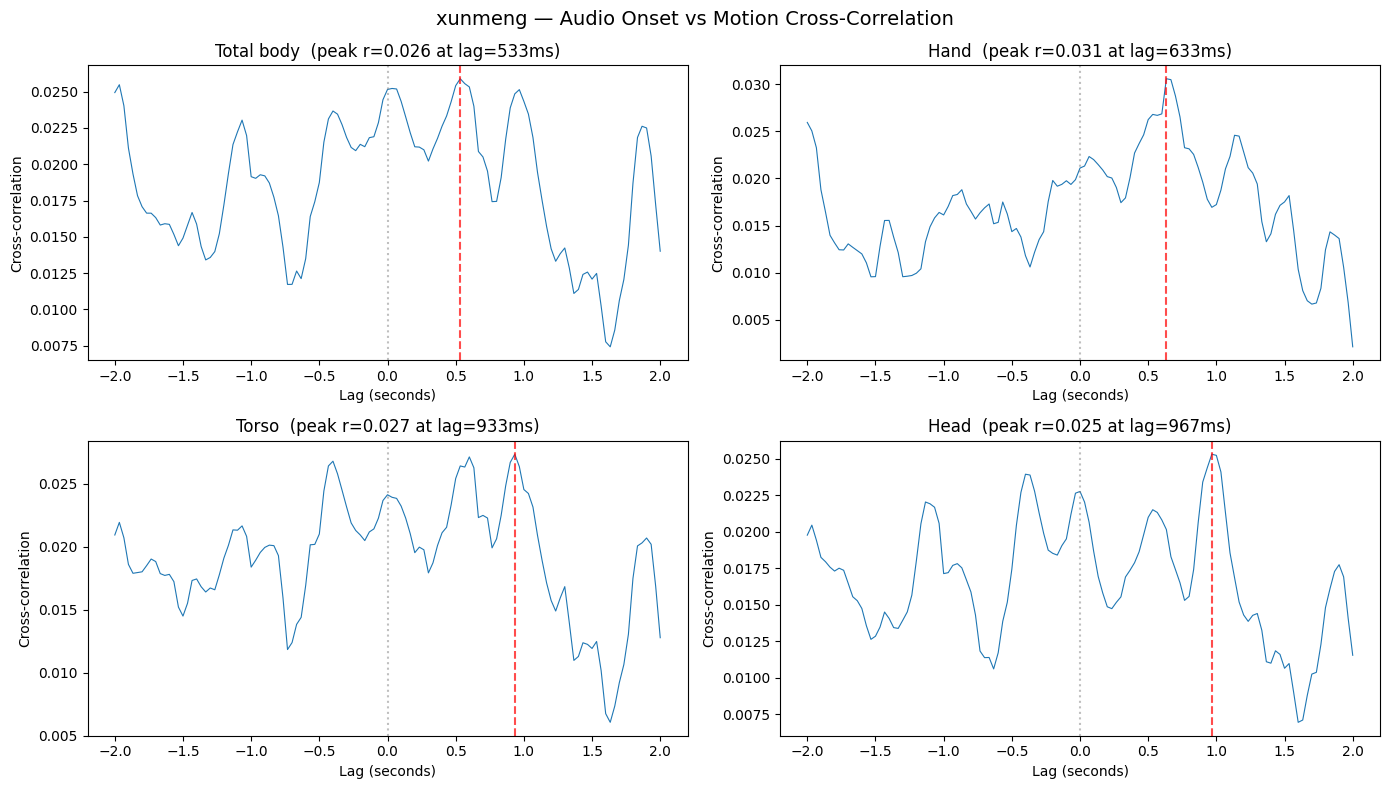

In [4]:
def compute_xcorr(sig_a, sig_b, valid_mask, max_lag_sec=2.0):
    """Compute normalized cross-correlation between two signals."""
    a = np.nan_to_num(sig_a[valid_mask])
    b = np.nan_to_num(sig_b[valid_mask])
    a = (a - a.mean()) / (a.std() + 1e-10)
    b = (b - b.mean()) / (b.std() + 1e-10)
    xcorr = correlate(a, b, mode="full") / len(a)
    lags = np.arange(-len(a) + 1, len(a)) / fps
    # Trim to max_lag
    mask = np.abs(lags) <= max_lag_sec
    return lags[mask], xcorr[mask]


valid = ~np.isnan(data["motion_total"]) & ~np.isnan(onset) & ~cut_mask

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, key) in zip(axes.flat, [
    ("Total body", "motion_total"),
    ("Hand", "motion_hand"),
    ("Torso", "motion_torso"),
    ("Head", "motion_head"),
]):
    v = ~np.isnan(data[key]) & ~np.isnan(onset) & ~cut_mask
    if v.sum() < 100:
        ax.set_title(f"{name} — insufficient data")
        continue
    lags, xcorr = compute_xcorr(onset, data[key], v)
    ax.plot(lags, xcorr, lw=0.8)
    peak_idx = np.argmax(xcorr)
    peak_lag = lags[peak_idx]
    peak_val = xcorr[peak_idx]
    ax.axvline(peak_lag, color="red", ls="--", alpha=0.7)
    ax.axvline(0, color="gray", ls=":", alpha=0.5)
    ax.set_title(f"{name}  (peak r={peak_val:.3f} at lag={peak_lag*1000:.0f}ms)")
    ax.set_xlabel("Lag (seconds)")
    ax.set_ylabel("Cross-correlation")

fig.suptitle(f"{VIDEO_ID} — Audio Onset vs Motion Cross-Correlation", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Windowed Correlation Over Time

How does the audio-motion coupling vary throughout the performance?
Sliding 10-second windows with 50% overlap.

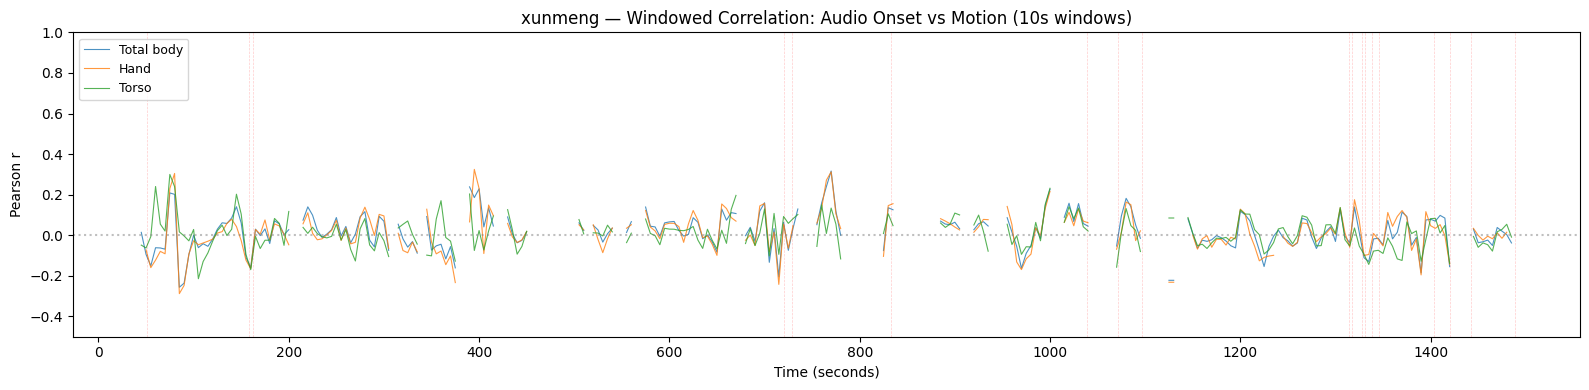

In [5]:
window_sec = 10
window = window_sec * fps
step = window // 2

windowed_corrs = {"time": [], "onset_vs_total": [], "onset_vs_hand": [], "onset_vs_torso": []}

for i in range(0, len(times) - window, step):
    s = slice(i, i + window)
    t_mid = times[i + window // 2]
    
    for label, motion_key in [
        ("onset_vs_total", "motion_total"),
        ("onset_vs_hand", "motion_hand"),
        ("onset_vs_torso", "motion_torso"),
    ]:
        v = ~np.isnan(onset[s]) & ~np.isnan(data[motion_key][s]) & ~cut_mask[s]
        if v.sum() > window * 0.3:
            r, _ = pearsonr(onset[s][v], data[motion_key][s][v])
        else:
            r = np.nan
        windowed_corrs[label].append(r)
    windowed_corrs["time"].append(t_mid)

fig, ax = plt.subplots(figsize=(16, 4))
t = windowed_corrs["time"]
ax.plot(t, windowed_corrs["onset_vs_total"], lw=0.8, label="Total body", alpha=0.8)
ax.plot(t, windowed_corrs["onset_vs_hand"], lw=0.8, label="Hand", alpha=0.8)
ax.plot(t, windowed_corrs["onset_vs_torso"], lw=0.8, label="Torso", alpha=0.8)
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_ylabel("Pearson r")
ax.set_xlabel("Time (seconds)")
ax.set_title(f"{VIDEO_ID} — Windowed Correlation: Audio Onset vs Motion ({window_sec}s windows)")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.0)

for cf in shot_data["cuts"]:
    ax.axvline(cf / shot_data["video_fps"], color="red", ls="--", alpha=0.2, lw=0.5)

plt.tight_layout()
plt.show()

## 5. Pitch Contour vs Head Motion

In Kunqu, head movement may track melodic contour. Compare f0 (pitch) with head motion.

Pitch delta vs head motion: r=0.0053, p=4.87e-01, N=16932


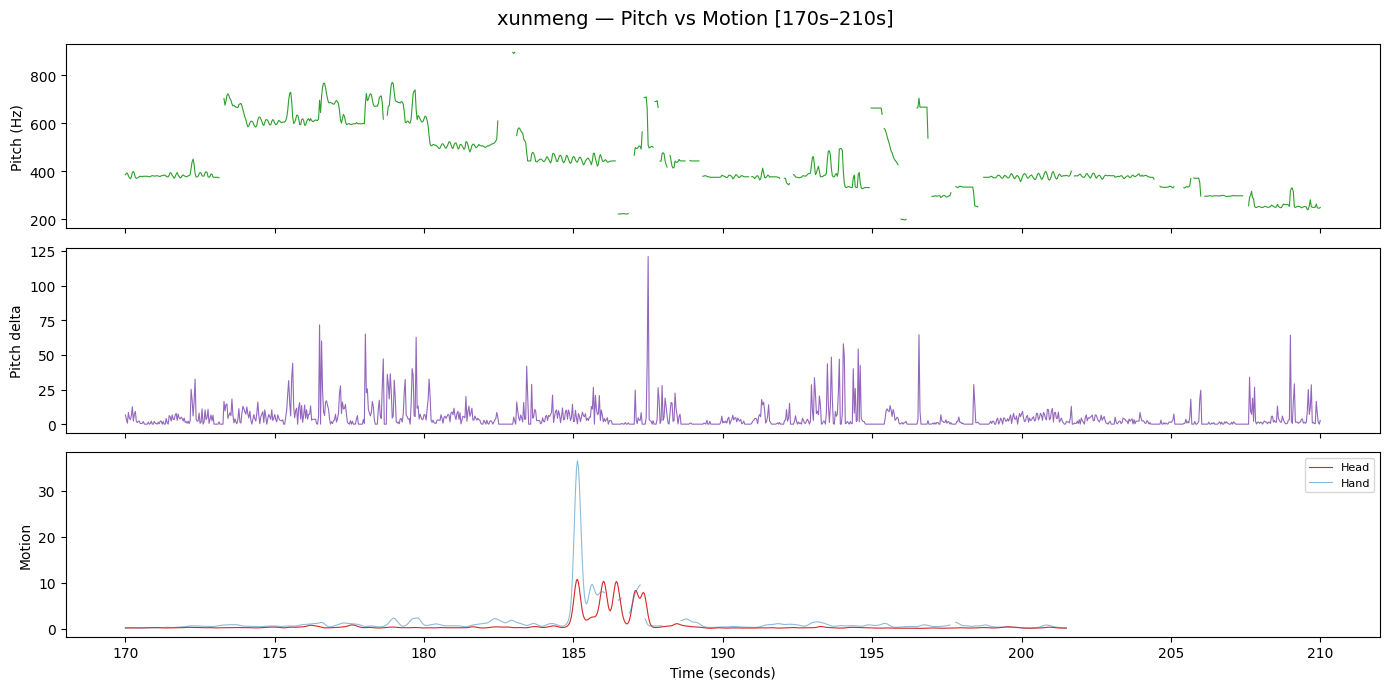

In [6]:
f0 = data["audio_f0"]
head = data["motion_head"]
pdelta = data["audio_pitch_delta"]

# Pitch delta vs head motion — does head move more during melodic jumps?
v = ~np.isnan(pdelta) & ~np.isnan(head) & ~cut_mask & (pdelta > 0)
if v.sum() > 100:
    r, p = pearsonr(pdelta[v], head[v])
    print(f"Pitch delta vs head motion: r={r:.4f}, p={p:.2e}, N={v.sum()}")

# Visualize a segment
seg_start, seg_end = 170, 210  # seconds — adjust as needed
mask = (times >= seg_start) & (times <= seg_end)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(times[mask], f0[mask], lw=0.8, color="C2")
axes[0].set_ylabel("Pitch (Hz)")

axes[1].plot(times[mask], pdelta[mask], lw=0.8, color="C4")
axes[1].set_ylabel("Pitch delta")

axes[2].plot(times[mask], head[mask], lw=0.8, color="C3", label="Head")
axes[2].plot(times[mask], data["motion_hand"][mask], lw=0.8, color="C0", alpha=0.5, label="Hand")
axes[2].set_ylabel("Motion")
axes[2].legend(fontsize=8)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"{VIDEO_ID} — Pitch vs Motion [{seg_start}s–{seg_end}s]", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Segment Analysis

Analyze each continuous shot independently to avoid cross-cut artifacts.

In [7]:
video_fps = shot_data["video_fps"]

print(f"{'Segment':<10s}  {'Start':>7s}  {'End':>7s}  {'Dur(s)':>7s}  {'r(onset,total)':>15s}  {'r(onset,hand)':>15s}")
print("-" * 72)

seg_results = []
for i, seg in enumerate(shot_data["segments"]):
    # Convert from video frames to common timeline frames
    t_start = seg["start_frame"] / video_fps
    t_end = seg["end_frame"] / video_fps
    s = (times >= t_start) & (times <= t_end)
    
    dur = seg["duration_sec"]
    
    row = {"seg": i, "start": t_start, "end": t_end, "dur": dur}
    
    for label, motion_key in [("r_total", "motion_total"), ("r_hand", "motion_hand")]:
        v = s & ~np.isnan(onset) & ~np.isnan(data[motion_key]) & ~cut_mask
        if v.sum() > 30:
            r, _ = pearsonr(onset[v], data[motion_key][v])
            row[label] = r
        else:
            row[label] = np.nan
    
    seg_results.append(row)
    r_t = f"{row.get('r_total', np.nan):.3f}" if not np.isnan(row.get('r_total', np.nan)) else "n/a"
    r_h = f"{row.get('r_hand', np.nan):.3f}" if not np.isnan(row.get('r_hand', np.nan)) else "n/a"
    print(f"  {i:<8d}  {t_start:>6.1f}s  {t_end:>6.1f}s  {dur:>6.1f}s  {r_t:>15s}  {r_h:>15s}")

Segment       Start      End   Dur(s)   r(onset,total)    r(onset,hand)
------------------------------------------------------------------------
  0            0.0s    51.4s    51.5s            0.002            0.020
  1           51.5s   157.7s   106.3s            0.035            0.026
  2          157.8s   162.5s     4.8s              n/a              n/a
  3          162.5s   720.8s   558.3s            0.015            0.006
  4          720.8s   729.1s     8.3s            0.098            0.067
  5          729.1s   832.8s   103.7s           -0.001            0.017
  6          832.8s  1038.4s   205.6s            0.055            0.065
  7         1038.4s  1071.8s    33.4s           -0.087           -0.056
  8         1071.8s  1097.0s    25.2s            0.100            0.066
  9         1097.0s  1314.0s   217.1s           -0.000           -0.002
  10        1314.1s  1317.5s     3.5s           -0.031           -0.028
  11        1317.5s  1328.1s    10.6s            0.095         

## 7. Data Quality Summary

Overview of NaN coverage and signal statistics.

In [8]:
print("Signal NaN fractions:")
print(f"  {'Signal':<25s}  {'NaN %':>8s}  {'Mean':>10s}  {'Std':>10s}")
print("  " + "-" * 58)
for key in sorted(data.files):
    if key in ("times", "cut_mask"):
        continue
    arr = data[key]
    nan_pct = np.isnan(arr).mean() * 100
    valid_vals = arr[~np.isnan(arr)]
    mean = np.mean(valid_vals) if len(valid_vals) > 0 else 0
    std = np.std(valid_vals) if len(valid_vals) > 0 else 0
    print(f"  {key:<25s}  {nan_pct:>7.1f}%  {mean:>10.3f}  {std:>10.3f}")

print(f"\nCut mask coverage: {cut_mask.mean()*100:.1f}% of frames")
print(f"Motion metadata: root_mode={meta['motion']['root_mode_resolved']}, "
      f"scale_cv={meta['motion']['scale_reference_cv']}")

Signal NaN fractions:
  Signal                        NaN %        Mean         Std
  ----------------------------------------------------------
  audio_f0                      18.9%     406.655     139.770
  audio_onset                    0.0%       1.455       1.184
  audio_pitch_delta              0.0%       3.455       7.766
  audio_rms                      0.0%       0.055       0.048
  motion_hand                   37.9%       0.775       1.030
  motion_hand_left              41.4%       0.763       1.064
  motion_hand_right             48.3%       0.760       1.094
  motion_head                   34.3%       0.219       0.467
  motion_root_displacement      34.0%     119.145     293.271
  motion_torso                  34.3%       0.187       0.306
  motion_total                  34.3%       0.389       0.565
  motion_upper_body             34.3%       0.291       0.509

Cut mask coverage: 0.2% of frames
Motion metadata: root_mode=hip, scale_cv=0.3631
